## ARIMA Model Implementation

In [4]:
# Importing libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data download
import yfinance as yf

# Statistical tests and ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
# Download daily stock data for Coca-Cola (KO) and PepsiCo (PEP)
data = yf.download(['KO', 'PEP'], start='2005-01-01', auto_adjust=False)

# Keep only the closing prices
close_prices = data['Close'][['KO', 'PEP']].dropna()

# Display first few rows
close_prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2005-01-03,20.770,51.939999
2005-01-04,20.480,51.570000
2005-01-05,20.385,51.630001
2005-01-06,20.555,52.000000
2005-01-07,20.580,52.450001


In [6]:
# Display basic information about the dataset
print("Dataset shape:", close_prices.shape)
print("\nMissing values:\n", close_prices.isnull().sum())

# Display last few rows to confirm latest available dates
close_prices.tail()

Dataset shape: (5356, 2)

Missing values:
 Ticker
KO     0
PEP    0
dtype: int64


Ticker,KO,PEP
Date,,
2026-04-13,76.410004,155.880005
2026-04-14,75.900002,155.720001
2026-04-15,75.309998,154.850006
2026-04-16,75.180000,158.380005
2026-04-17,75.739998,157.669998


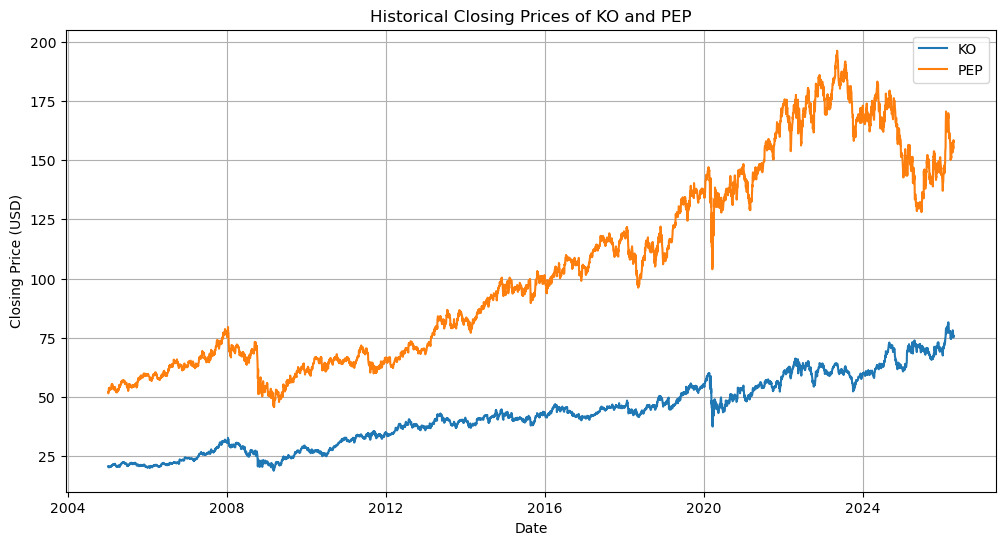

In [7]:
# Plot historical closing prices for both stocks
plt.figure(figsize=(12, 6))
plt.plot(close_prices.index, close_prices['KO'], label='KO')
plt.plot(close_prices.index, close_prices['PEP'], label='PEP')

plt.title('Historical Closing Prices of KO and PEP')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Function to perform Augmented Dickey-Fuller (ADF) test
# This helps us check whether a time series is stationary
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    
    print(f"ADF Test for {name}")
    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    
    # Interpretation based on p-value
    if result[1] < 0.05:
        print("Result        : Stationary (reject H0)")
    else:
        print("Result        : Non-stationary (fail to reject H0)")

In [9]:
# ADF test on original price series
adf_test(close_prices['KO'], 'KO Closing Price')
print()
adf_test(close_prices['PEP'], 'PEP Closing Price')

ADF Test for KO Closing Price
ADF Statistic : -0.545049
p-value       : 0.882922
Lags Used     : 7
Observations  : 5348
Result        : Non-stationary (fail to reject H0)

ADF Test for PEP Closing Price
ADF Statistic : -0.777149
p-value       : 0.825742
Lags Used     : 32
Observations  : 5323
Result        : Non-stationary (fail to reject H0)


In [10]:
# Reserve the last 10 observations for testing
# This matches the required 10-day forecast horizon
train = close_prices.iloc[:-10]
test = close_prices.iloc[-10:]

print("Training data shape:", train.shape)
print("Test data shape    :", test.shape)

print("\nTest period:")
print(test.index)

Training data shape: (5346, 2)
Test data shape    : (10, 2)

Test period:
DatetimeIndex(['2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15',
               '2026-04-16', '2026-04-17'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [11]:
# Use auto-ARIMA to automatically find the best (p, d, q) parameters for KO

auto_model_ko = auto_arima(
    train['KO'],
    seasonal=False, # seasonal=False because we scope is a non-seasonal ARIMA model
    trace=True,          # shows model search process
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

# Display selected order
print("Best ARIMA order for KO:", auto_model_ko.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7622.572, Time=4.75 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7626.674, Time=1.33 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7623.084, Time=0.45 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7623.225, Time=1.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7627.077, Time=0.30 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7625.963, Time=5.42 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=7626.049, Time=5.00 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=7603.205, Time=12.19 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=7622.348, Time=6.44 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=7595.377, Time=10.85 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=7593.410, Time=6.83 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=7608.940, Time=1.39 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=7595.390, Time=8.31 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=7624.817, Time=1.03 sec
 ARIMA(5,1,0)(0,0,0)[0] interce

In [12]:
# Fit the final ARIMA model for KO using the best order from auto-ARIMA
ko_order = auto_model_ko.order

ko_model = ARIMA(train['KO'], order=ko_order)
ko_model_fit = ko_model.fit()

# Display model summary
print(ko_model_fit.summary())

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                 5346
Model:                 ARIMA(4, 1, 1)   Log Likelihood               -3791.086
Date:                Sat, 18 Apr 2026   AIC                           7594.171
Time:                        14:27:29   BIC                           7633.675
Sample:                             0   HQIC                          7607.970
                               - 5346                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7228      0.045    -16.201      0.000      -0.810      -0.635
ar.L2         -0.0078      0.009     -0.851      0.395      -0.026       0.010
ar.L3         -0.0084      0.009     -0.940      0.3

In [13]:
# Forecast next 10 days
ko_forecast = ko_model_fit.forecast(steps=10)

# Convert to pandas Series with correct alignment
ko_forecast = pd.Series(ko_forecast.values, index=test.index, name='KO_ARIMA_Forecast')

# Display forecast
ko_forecast

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2026-04-06    76.758101
2026-04-07    76.740525
2026-04-08    76.745491
2026-04-09    76.697462
2026-04-10    76.729651
2026-04-13    76.707934
2026-04-14    76.723439
2026-04-15    76.715453
2026-04-16    76.719060
2026-04-17    76.717887
Name: KO_ARIMA_Forecast, dtype: float64

In [14]:
# Calculate forecast accuracy metrics for KO
ko_rmse = np.sqrt(mean_squared_error(test['KO'], ko_forecast))
ko_mae = mean_absolute_error(test['KO'], ko_forecast)
ko_mape = np.mean(np.abs((test['KO'] - ko_forecast) / test['KO'])) * 100

print("KO ARIMA Forecast Performance")
print(f"RMSE : {ko_rmse:.4f}")
print(f"MAE  : {ko_mae:.4f}")
print(f"MAPE : {ko_mape:.2f}%")

KO ARIMA Forecast Performance
RMSE : 1.0006
MAE  : 0.9104
MAPE : 1.19%


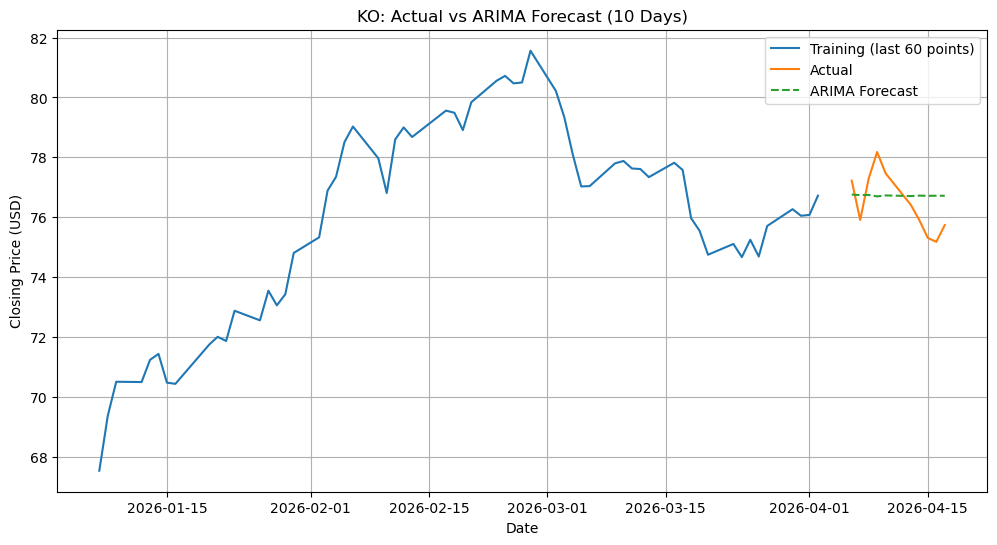

In [15]:
# Plot actual vs forecasted values for KO
plt.figure(figsize=(12, 6))
plt.plot(train.index[-60:], train['KO'][-60:], label='Training (last 60 points)')
plt.plot(test.index, test['KO'], label='Actual')
plt.plot(test.index, ko_forecast, label='ARIMA Forecast', linestyle='--')

plt.title('KO: Actual vs ARIMA Forecast (10 Days)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Use auto-ARIMA to automatically find the best (p, d, q) parameters for PEP
auto_model_pep = auto_arima(
    train['PEP'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

# Display selected order
print("Best ARIMA order for PEP:", auto_model_pep.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=17831.466, Time=8.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17949.380, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17881.464, Time=0.64 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17885.372, Time=0.74 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=17948.609, Time=0.21 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=17881.929, Time=3.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=17882.115, Time=4.20 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=17831.661, Time=8.38 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=17831.588, Time=14.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=17880.459, Time=1.89 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=17879.609, Time=4.26 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=17881.728, Time=3.70 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=17831.970, Time=16.03 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=17830.882, Time=2.73 sec
 ARIMA(1,1,2)(0,0

In [17]:
# Fit the final ARIMA model for PEP using the best order from auto-ARIMA
pep_order = auto_model_pep.order

pep_model = ARIMA(train['PEP'], order=pep_order)
pep_model_fit = pep_model.fit()

# Display model summary
print(pep_model_fit.summary())

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    PEP   No. Observations:                 5346
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8910.441
Date:                Sat, 18 Apr 2026   AIC                          17830.882
Time:                        14:29:06   BIC                          17863.802
Sample:                             0   HQIC                         17842.381
                               - 5346                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6025      0.022    -72.431      0.000      -1.646      -1.559
ar.L2         -0.7496      0.023    -33.214      0.000      -0.794      -0.705
ma.L1          1.5106      0.025     60.212      0.0

In [18]:
# Forecast the next 10 days for PEP
pep_forecast = pep_model_fit.forecast(steps=10)

# Convert forecast to a pandas Series with test dates as index
pep_forecast = pd.Series(pep_forecast.values, index=test.index, name='PEP_ARIMA_Forecast')

# Display forecast values
pep_forecast

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2026-04-06    156.863851
2026-04-07    156.996184
2026-04-08    156.893662
2026-04-09    156.958763
2026-04-10    156.931285
2026-04-13    156.926521
2026-04-14    156.954752
2026-04-15    156.913082
2026-04-16    156.958699
2026-04-17    156.916831
Name: PEP_ARIMA_Forecast, dtype: float64

In [19]:
# Calculate forecast accuracy metrics for PEP
pep_rmse = np.sqrt(mean_squared_error(test['PEP'], pep_forecast))
pep_mae = mean_absolute_error(test['PEP'], pep_forecast)
pep_mape = np.mean(np.abs((test['PEP'] - pep_forecast) / test['PEP'])) * 100

print("PEP ARIMA Forecast Performance")
print(f"RMSE : {pep_rmse:.4f}")
print(f"MAE  : {pep_mae:.4f}")
print(f"MAPE : {pep_mape:.2f}%")

PEP ARIMA Forecast Performance
RMSE : 1.6882
MAE  : 1.3192
MAPE : 0.85%


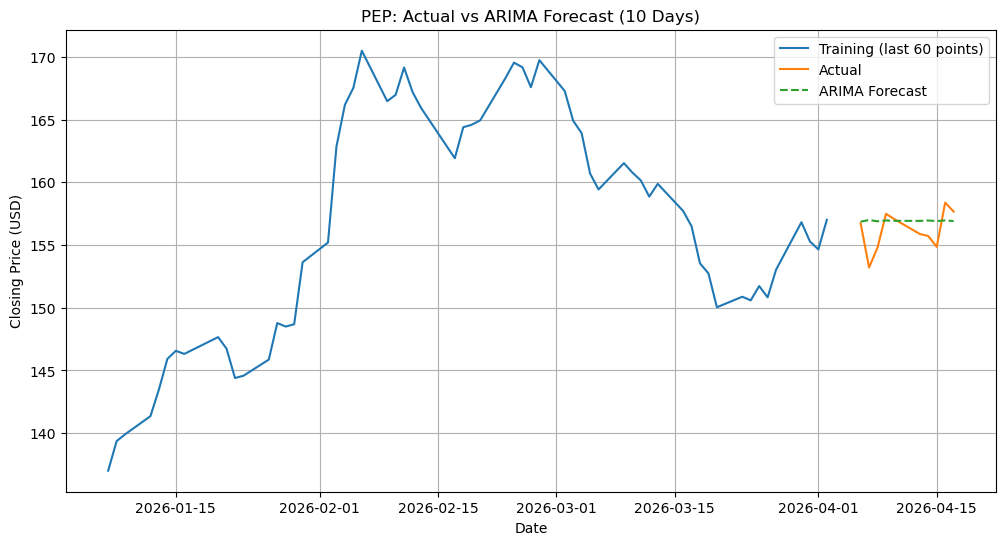

In [20]:
# Plot actual vs forecasted values for PEP
plt.figure(figsize=(12, 6))
plt.plot(train.index[-60:], train['PEP'][-60:], label='Training (last 60 points)')
plt.plot(test.index, test['PEP'], label='Actual')
plt.plot(test.index, pep_forecast, label='ARIMA Forecast', linestyle='--')

plt.title('PEP: Actual vs ARIMA Forecast (10 Days)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Create a summary table for easier comparison
results_df = pd.DataFrame({
    'Stock': ['KO', 'PEP'],
    'Best_ARIMA_Order': [ko_order, pep_order],
    'RMSE': [ko_rmse, pep_rmse],
    'MAE': [ko_mae, pep_mae],
    'MAPE (%)': [ko_mape, pep_mape]
})

results_df

,Stock,Best_ARIMA_Order,RMSE,MAE,MAPE (%)
0,KO,"(4, 1, 1)",1.000637,0.910359,1.192804
1,PEP,"(2, 1, 2)",1.688156,1.319246,0.850009


In [22]:
# Create a comparison table of actual vs forecast values for the test period
comparison_df = pd.DataFrame({
    'KO_Actual': test['KO'],
    'KO_Forecast': ko_forecast,
    'PEP_Actual': test['PEP'],
    'PEP_Forecast': pep_forecast
})

comparison_df

,KO_Actual,KO_Forecast,PEP_Actual,PEP_Forecast
Date,,,,
2026-04-06,77.220001,76.758101,156.729996,156.863851
2026-04-07,75.910004,76.740525,153.210007,156.996184
2026-04-08,77.290001,76.745491,154.800003,156.893662
2026-04-09,78.180000,76.697462,157.490005,156.958763
2026-04-10,77.470001,76.729651,157.059998,156.931285
2026-04-13,76.410004,76.707934,155.880005,156.926521
2026-04-14,75.900002,76.723439,155.720001,156.954752
2026-04-15,75.309998,76.715453,154.850006,156.913082
2026-04-16,75.180000,76.719060,158.380005,156.958699


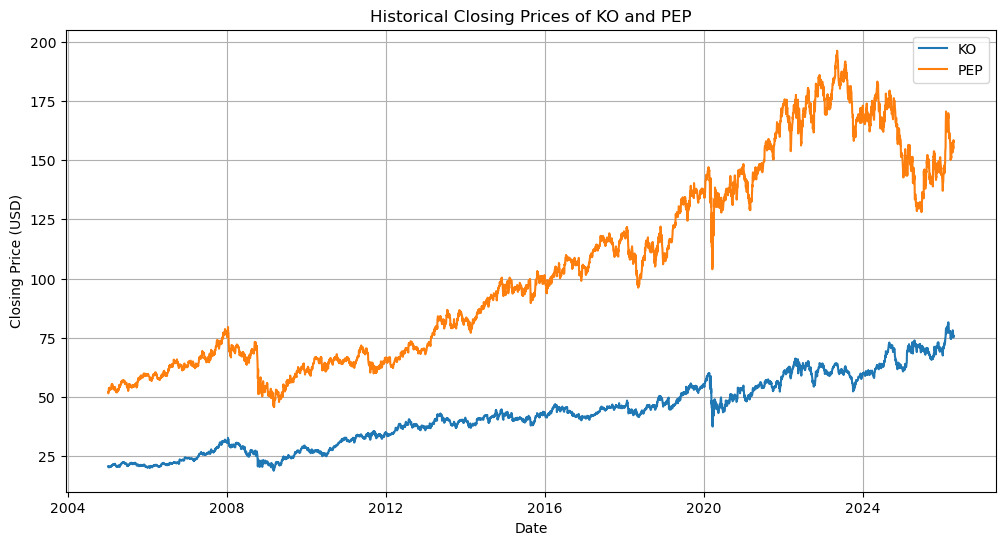

In [25]:
# Plot historical closing prices for both stocks
plt.figure(figsize=(12, 6))
plt.plot(close_prices.index, close_prices['KO'], label='KO')
plt.plot(close_prices.index, close_prices['PEP'], label='PEP')

plt.title('Historical Closing Prices of KO and PEP')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

END